## What is happening in the next code?
This code sets the project folder, the checkpoint folder, and the device (CPU), then lists the best saved checkpoint file for each model: ResNet18, ResNet34, and ResNet50.
It loops over them, stops with an error if a file is missing, and loads each checkpoint to read its best epoch, validation accuracy (in percent), and validation loss.
Finally, it shows these results in one table so you can compare the three models, and prints the device and a message that all three checkpoints were found.

In [1]:
from pathlib import Path
import pandas as pd
import torch

PROJECT_ROOT = Path(
    r"D:\Maktab_Sharif_Projects\traffic-vehicle-classification"
)
CHECKPOINT_DIR = PROJECT_ROOT / "outputs" / "checkpoints"
DEVICE = torch.device("cpu")

# Best retained checkpoint for each architecture.
BEST_CHECKPOINTS = {
    "resnet18": "resnet18_fc_layer34_best.pt",
    "resnet34": "resnet34_fc_layer34_best.pt",
    "resnet50": "resnet50_fc_layer4_best.pt",
}

rows = []

for architecture, filename in BEST_CHECKPOINTS.items():
    path = CHECKPOINT_DIR / filename

    if not path.is_file():
        raise FileNotFoundError(f"Missing checkpoint: {path}")

    checkpoint = torch.load(
        path,
        map_location="cpu",
        weights_only=True
    )

    rows.append({
        "architecture": architecture,
        "checkpoint": filename,
        "best_stage_epoch": checkpoint["epoch"],
        "saved_validation_accuracy_percent":
            checkpoint["val_accuracy"] * 100,
        "saved_validation_loss": checkpoint["val_loss"],
    })

display(pd.DataFrame(rows).round(4))
print("Device:", DEVICE)
print("Three checkpoints found.")

,architecture,checkpoint,best_stage_epoch,saved_validation_accuracy_percent,saved_validation_loss
0,resnet18,resnet18_fc_layer34_best.pt,10,97.5332,0.0788
1,resnet34,resnet34_fc_layer34_best.pt,5,97.3435,0.1071
2,resnet50,resnet50_fc_layer4_best.pt,1,97.3435,0.1194


Device: cpu
Three checkpoints found.


## What is happening in the next code?

* It loads the validation CSV and recovers the class mapping saved with the trained models.
* It checks that all model checkpoints use the same class-to-index mapping.
* It defines image preprocessing: orientation correction, RGB conversion, resize with padding, tensor conversion, and ImageNet normalization.
* It creates a custom `ValidationDataset` that loads each image and converts its label to its numerical index.
* It verifies that validation classes match the model classes and that image paths are unique.
* It creates a `DataLoader` with batches of 16 images and no shuffling.
* Finally, it loads the first validation batch and checks that the validation loader is ready.


In [2]:
from PIL import Image, ImageOps
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

val_df = pd.read_csv(
    PROJECT_ROOT / "data" / "manifests" / "validation.csv"
)

checkpoint = torch.load(
    CHECKPOINT_DIR / BEST_CHECKPOINTS["resnet18"],
    map_location="cpu",
    weights_only=True
)
class_to_idx = checkpoint["class_to_idx"]

for architecture, filename in BEST_CHECKPOINTS.items():
    saved = torch.load(
        CHECKPOINT_DIR / filename,
        map_location="cpu",
        weights_only=True
    )
    assert saved["class_to_idx"] == class_to_idx, (
        f"Class mapping mismatch: {architecture}"
    )

classes = sorted(class_to_idx, key=class_to_idx.get)

IMAGE_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]


class ResizeWithPadding:
    def __init__(self, size=224):
        self.size = size

    def __call__(self, image):
        image = ImageOps.exif_transpose(image).convert("RGB")
        image = ImageOps.contain(
            image,
            (self.size, self.size),
            method=Image.Resampling.BILINEAR
        )

        canvas = Image.new(
            "RGB",
            (self.size, self.size),
            color=(124, 116, 104)
        )
        canvas.paste(
            image,
            (
                (self.size - image.width) // 2,
                (self.size - image.height) // 2
            )
        )
        return canvas


val_transform = transforms.Compose([
    ResizeWithPadding(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


class ValidationDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        with Image.open(row["path"]) as image:
            image = val_transform(image)

        label = class_to_idx[row["label"]]
        return image, label


assert set(val_df["label"]) == set(class_to_idx)
assert val_df["path"].is_unique

val_dataset = ValidationDataset(val_df)
val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

images, labels = next(iter(val_loader))

print("Validation images:", len(val_dataset))
print("Classes:", classes)
print("Image batch shape:", images.shape)
print("Validation loader ready.")

Validation images: 527
Classes: ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
Image batch shape: torch.Size([16, 3, 224, 224])
Validation loader ready.


## What is happening in the next code?
This code tests the three best saved models (ResNet18, ResNet34, ResNet50) on the validation images, one model at a time. For each one, it builds an empty ResNet, replaces the last layer with an 8-class layer, loads the saved weights from the checkpoint, and switches to eval mode.
It runs all validation images through the model, and keeps the true labels, the predicted labels, and the probability of every class. From these it calculates accuracy, macro precision, macro recall, and macro F1, which treat all classes equally.
For each model it saves two CSV files: one with the prediction for every image (true class, predicted class, confidence, correct or not, class probabilities) and one with a per-class classification report.
Finally, it puts the results of all three models in one table sorted by macro F1 (then accuracy), saves it as `model_comparison.csv`, and displays it, so you can see which model is the best.

In [3]:
import numpy as np
import torch.nn as nn

from torchvision.models import resnet18, resnet34, resnet50
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
)

EVALUATION_DIR = PROJECT_ROOT / "outputs" / "validation"
EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

builders = {
    "resnet18": resnet18,
    "resnet34": resnet34,
    "resnet50": resnet50,
}

comparison_rows = []

for architecture, filename in BEST_CHECKPOINTS.items():
    print(f"Evaluating {architecture}...", flush=True)

    saved = torch.load(
        CHECKPOINT_DIR / filename,
        map_location="cpu",
        weights_only=True
    )

    model = builders[architecture](weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(classes))
    model.load_state_dict(saved["model_state_dict"])
    model = model.to(DEVICE)
    model.eval()

    true_labels = []
    predicted_labels = []
    probabilities = []

    with torch.inference_mode():
        for images, labels in val_loader:
            logits = model(images.to(DEVICE))
            batch_probabilities = torch.softmax(logits, dim=1)

            true_labels.extend(labels.tolist())
            predicted_labels.extend(
                logits.argmax(dim=1).cpu().tolist()
            )
            probabilities.extend(
                batch_probabilities.cpu().tolist()
            )

    probabilities = np.asarray(probabilities)
    label_ids = list(range(len(classes)))

    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(
            true_labels,
            predicted_labels,
            labels=label_ids,
            average="macro",
            zero_division=0
        )
    )

    accuracy = accuracy_score(true_labels, predicted_labels)

    comparison_rows.append({
        "architecture": architecture,
        "checkpoint": filename,
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
    })

    predictions = val_df.reset_index(drop=True).copy()
    predictions["true_class"] = [
        classes[index] for index in true_labels
    ]
    predictions["predicted_class"] = [
        classes[index] for index in predicted_labels
    ]
    predictions["confidence_percent"] = (
        probabilities.max(axis=1) * 100
    )
    predictions["correct"] = (
        predictions["true_class"] == predictions["predicted_class"]
    )

    for index, class_name in enumerate(classes):
        predictions[f"probability_{class_name}"] = probabilities[:, index]

    predictions.to_csv(
        EVALUATION_DIR / f"{architecture}_predictions.csv",
        index=False
    )

    report = classification_report(
        true_labels,
        predicted_labels,
        labels=label_ids,
        target_names=classes,
        output_dict=True,
        zero_division=0
    )
    pd.DataFrame(report).transpose().to_csv(
        EVALUATION_DIR / f"{architecture}_classification_report.csv"
    )

    print(
        f"{architecture}: accuracy = {accuracy:.2%}, "
        f"macro-F1 = {macro_f1:.4f}, "
        f"errors = {sum(not value for value in predictions['correct'])}",
        flush=True
    )

    del model

comparison = pd.DataFrame(comparison_rows).sort_values(
    ["macro_f1", "accuracy"],
    ascending=[False, False]
).reset_index(drop=True)

comparison.to_csv(
    EVALUATION_DIR / "model_comparison.csv",
    index=False
)

display(
    comparison.style.format({
        "accuracy": "{:.2%}",
        "macro_precision": "{:.4f}",
        "macro_recall": "{:.4f}",
        "macro_f1": "{:.4f}",
    })
)

print("Results saved:", EVALUATION_DIR)

Evaluating resnet18...
resnet18: accuracy = 97.53%, macro-F1 = 0.9748, errors = 13
Evaluating resnet34...
resnet34: accuracy = 97.34%, macro-F1 = 0.9744, errors = 14
Evaluating resnet50...
resnet50: accuracy = 97.34%, macro-F1 = 0.9735, errors = 14


,architecture,checkpoint,accuracy,macro_precision,macro_recall,macro_f1
0,resnet18,resnet18_fc_layer34_best.pt,97.53%,0.9755,0.9745,0.9748
1,resnet34,resnet34_fc_layer34_best.pt,97.34%,0.9739,0.9750,0.9744
2,resnet50,resnet50_fc_layer4_best.pt,97.34%,0.9735,0.9737,0.9735


Results saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\validation


## What is happening in the next code?
This code looks at the mistakes each model (ResNet18, ResNet34, ResNet50) made on the validation images. For each model, it reads the saved predictions file and keeps only the rows where the predicted class is different from the true class.
It sorts these errors from the highest confidence to the lowest, so the most "sure but wrong" predictions come first, saves them as `<model>_errors.csv`, and shows a table that counts how many times each true class was confused with each predicted class.
Then it draws a grid with every wrong image, showing its true class, its predicted class, and the confidence. The figure is saved as a PNG in the `figures` folder. If a model made no errors, it skips the drawing.


resnet18: 13 validation errors


,true_class,predicted_class,error_count
0,ambulance,savari,1
1,ambulance,vanet,2
2,kamyun,autobus,1
3,kamyun,kamyunet,1
4,kamyunet,kamyun,1
5,kamyunet,vanet,1
6,minibus,autobus,1
7,savari,taxi,1
8,savari,vanet,1
9,vanet,autobus,1


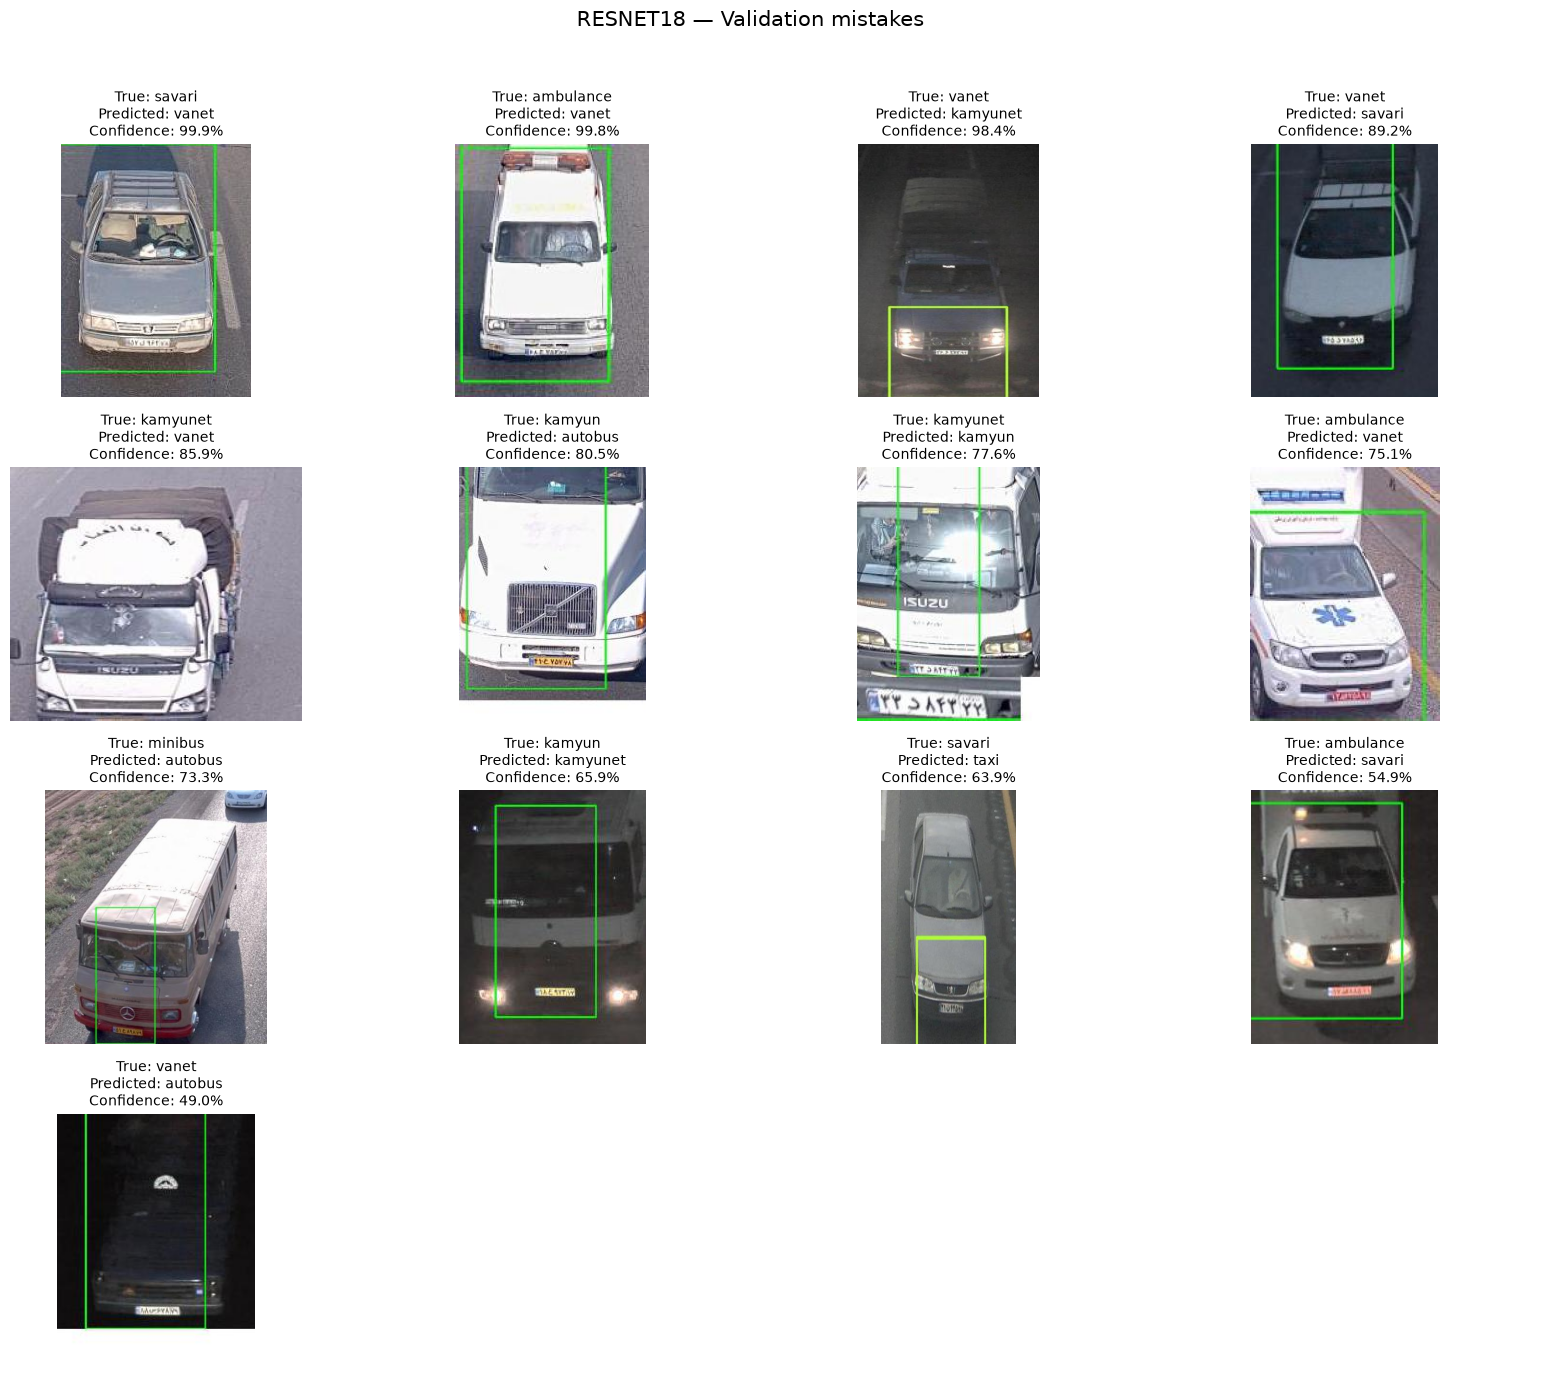

Figure saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\figures\resnet18_validation_errors.png

resnet34: 14 validation errors


,true_class,predicted_class,error_count
0,ambulance,vanet,1
1,autobus,kamyunet,1
2,autobus,minibus,1
3,kamyun,autobus,1
4,kamyun,kamyunet,1
5,kamyunet,kamyun,2
6,kamyunet,vanet,2
7,minibus,kamyun,1
8,savari,vanet,1
9,vanet,kamyunet,1


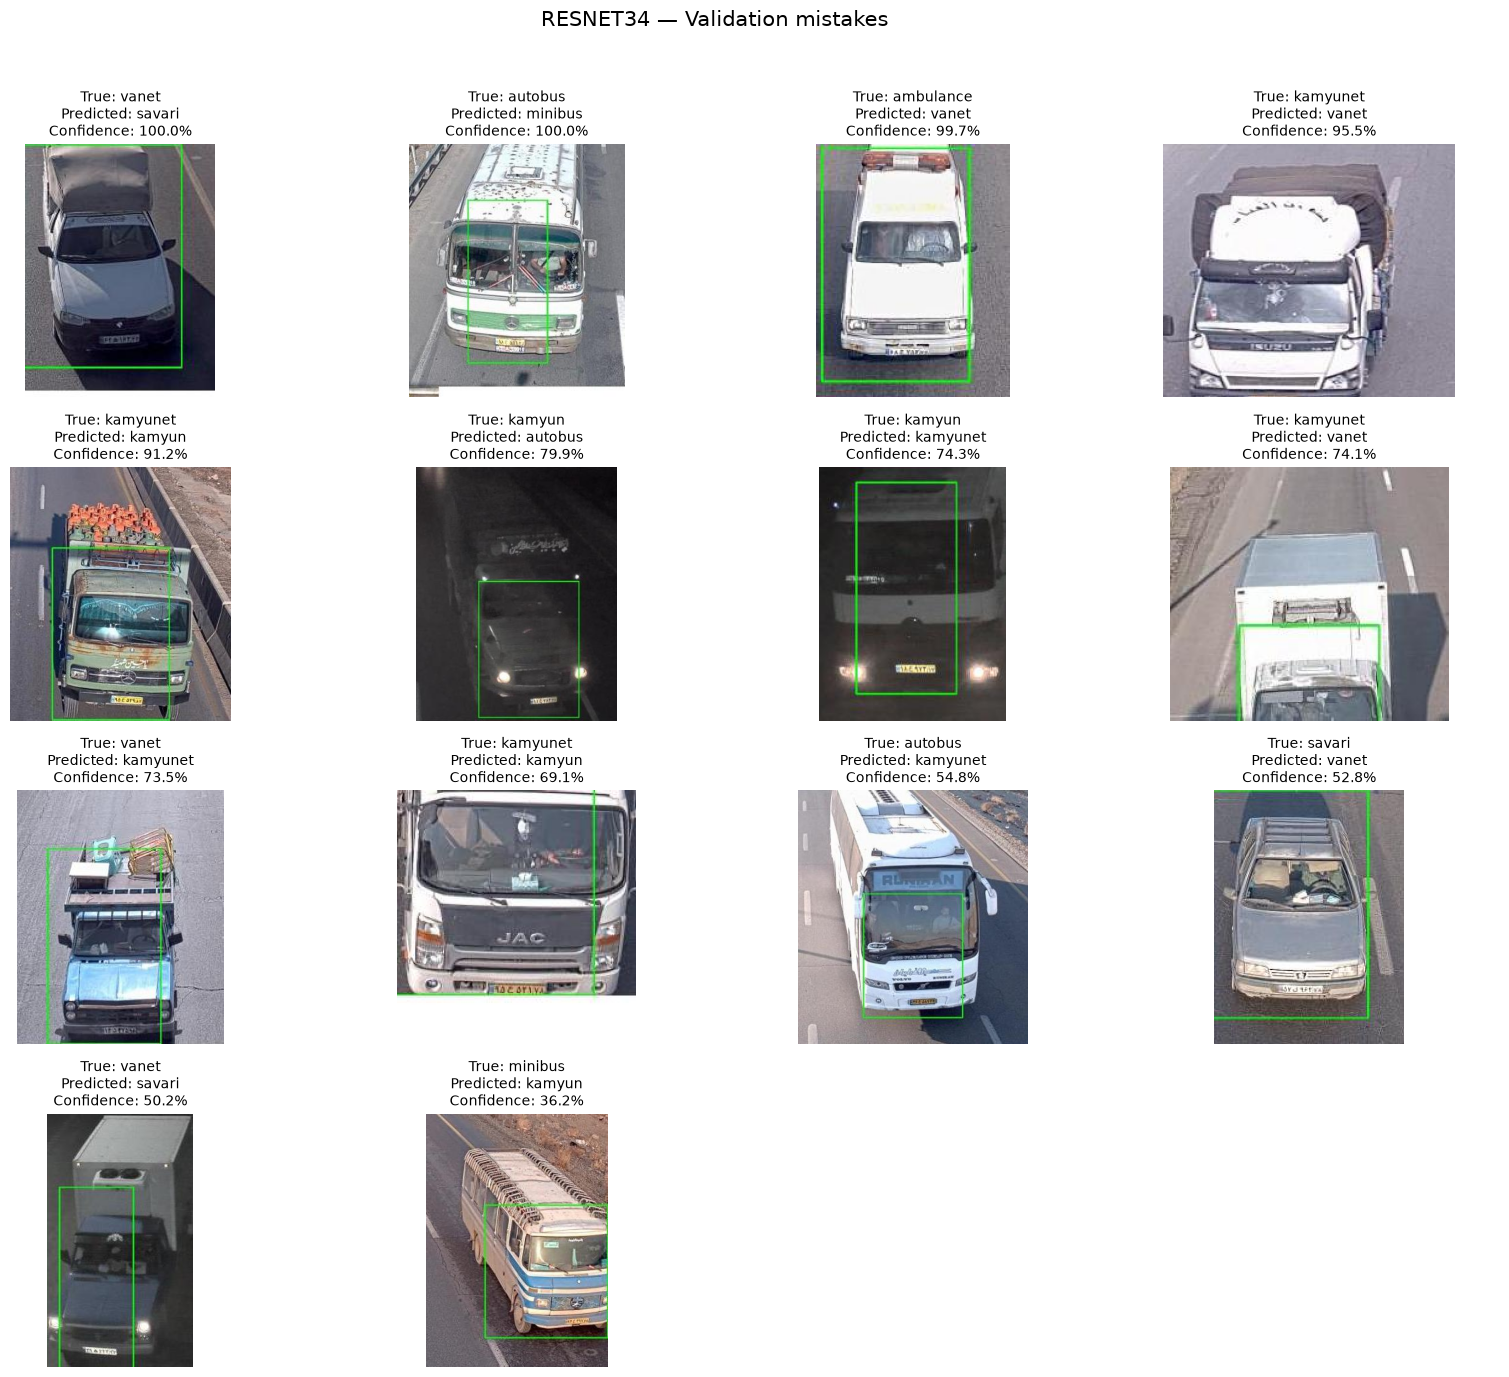

Figure saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\figures\resnet34_validation_errors.png

resnet50: 14 validation errors


,true_class,predicted_class,error_count
0,ambulance,vanet,1
1,autobus,minibus,1
2,kamyun,autobus,2
3,kamyun,kamyunet,1
4,kamyun,minibus,1
5,kamyunet,kamyun,3
6,savari,vanet,1
7,taxi,savari,1
8,vanet,kamyunet,1
9,vanet,savari,2


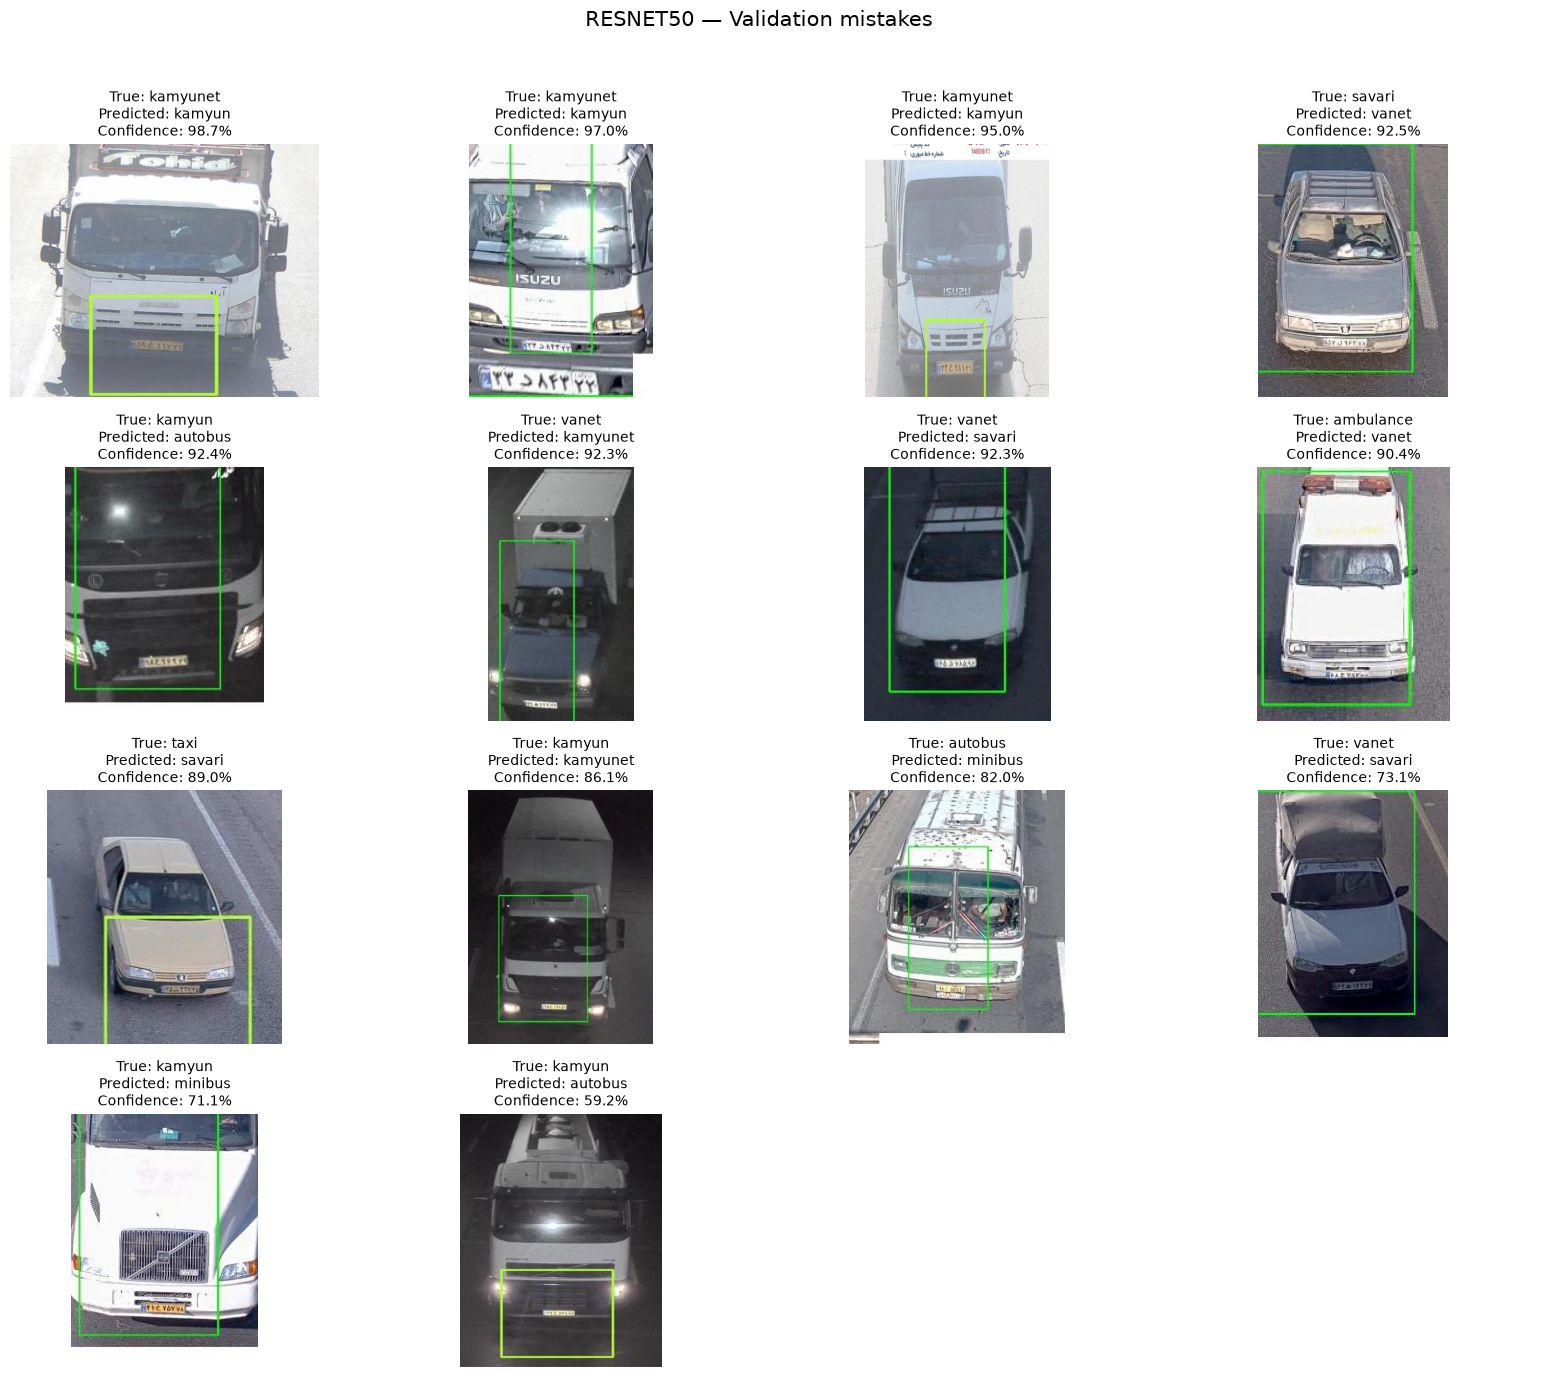

Figure saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\figures\resnet50_validation_errors.png


In [4]:
import math
import matplotlib.pyplot as plt

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

for architecture in BEST_CHECKPOINTS:
    predictions = pd.read_csv(
        EVALUATION_DIR / f"{architecture}_predictions.csv"
    )

    errors = predictions[
        predictions["true_class"] != predictions["predicted_class"]
    ].copy()

    errors = errors.sort_values(
        "confidence_percent", ascending=False
    ).reset_index(drop=True)

    errors.to_csv(
        EVALUATION_DIR / f"{architecture}_errors.csv",
        index=False
    )

    print(f"\n{architecture}: {len(errors)} validation errors")
    display(
        errors.groupby(
            ["true_class", "predicted_class"]
        ).size().reset_index(name="error_count")
    )

    if errors.empty:
        continue

    columns = 4
    rows = math.ceil(len(errors) / columns)

    fig, axes = plt.subplots(
        rows, columns,
        figsize=(16, rows * 3.5),
        squeeze=False
    )

    for ax in axes.ravel():
        ax.axis("off")

    for ax, (_, row) in zip(axes.ravel(), errors.iterrows()):
        with Image.open(row["path"]) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")
            ax.imshow(image)

        ax.set_title(
            f"True: {row['true_class']}\n"
            f"Predicted: {row['predicted_class']}\n"
            f"Confidence: {row['confidence_percent']:.1f}%",
            fontsize=10
        )

    fig.suptitle(
        f"{architecture.upper()} — Validation mistakes",
        fontsize=15
    )
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    figure_path = FIGURE_DIR / f"{architecture}_validation_errors.png"
    fig.savefig(figure_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("Figure saved:", figure_path)

In [5]:
report = pd.read_csv(
    EVALUATION_DIR / "resnet18_classification_report.csv",
    index_col=0
)

display(
    report.loc[
        classes,
        ["precision", "recall", "f1-score", "support"]
    ].round(4)
)

,precision,recall,f1-score,support
ambulance,1.0000,0.9508,0.9748,61.0
autobus,0.9630,1.0000,0.9811,78.0
kamyun,0.9846,0.9697,0.9771,66.0
kamyunet,0.9783,0.9783,0.9783,92.0
minibus,1.0000,0.9846,0.9922,65.0
savari,0.9623,0.9623,0.9623,53.0
taxi,0.9811,1.0000,0.9905,52.0
vanet,0.9344,0.9500,0.9421,60.0


## What is happening in the next code?
This code prepares a dropout experiment on the best ResNet18 model. It will test three dropout values (0.0, 0.25, 0.5), 10 epochs each, with seed 42, and creates a `dropout` output folder.
The function `build_dropout_model` builds a ResNet18, loads the saved weights from the best ResNet18 checkpoint, and puts a Dropout layer in front of the final layer, keeping the learned classifier weights. Dropout randomly turns off some neurons during training, which helps reduce overfitting.
It then freezes all layers and unfreezes only `layer3`, `layer4`, and the final block, the same layers trained before.
Finally, it builds a preview model with dropout 0.25 and prints the starting checkpoint, the dropout values, the epochs, the new classifier, and the number of trainable parameters.

In [6]:
from torchvision.models import resnet18

DROPOUT_VALUES = [0.0, 0.25, 0.5]
DROPOUT_EPOCHS = 10
DROPOUT_SEED = 42

DROPOUT_START_PATH = (
    CHECKPOINT_DIR / "resnet18_fc_layer34_best.pt"
)

DROPOUT_DIR = PROJECT_ROOT / "outputs" / "dropout"
DROPOUT_DIR.mkdir(parents=True, exist_ok=True)


def build_dropout_model(dropout_probability):
    saved = torch.load(
        DROPOUT_START_PATH,
        map_location="cpu",
        weights_only=True
    )

    model = resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(classes))
    model.load_state_dict(saved["model_state_dict"])

    # Keep the learned classifier weights and add dropout before it.
    classifier = model.fc
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_probability),
        classifier
    )

    # Train the same layers as the selected ResNet18 model.
    for parameter in model.parameters():
        parameter.requires_grad = False

    for layer in [model.layer3, model.layer4, model.fc]:
        for parameter in layer.parameters():
            parameter.requires_grad = True

    return model.to(DEVICE)


dropout_preview = build_dropout_model(0.25)

print("Starting checkpoint:", DROPOUT_START_PATH.name)
print("Dropout values:", DROPOUT_VALUES)
print("Epochs per experiment:", DROPOUT_EPOCHS)
print("Classifier:", dropout_preview.fc)
print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in dropout_preview.parameters()
        if p.requires_grad
    )
)

del dropout_preview

Starting checkpoint: resnet18_fc_layer34_best.pt
Dropout values: [0.0, 0.25, 0.5]
Epochs per experiment: 10
Classifier: Sequential(
  (0): Dropout(p=0.25, inplace=False)
  (1): Linear(in_features=512, out_features=8, bias=True)
)
Trainable parameters: 10497544


## What is happening in the next code?
This code prepares the training data for the dropout experiment. It loads the training CSV and builds the training transform: fix rotation, random horizontal flip, small color changes, resize to 224x224 with gray padding, and normalization.
A `TrainingDataset` class loads one image, applies this transform, and turns its label into a number. The function `make_dropout_train_loader` creates a loader with 16 images per batch and shuffling, using a fixed seed (42), so every dropout experiment sees the images in the same order and the comparison is fair.
Finally, it checks that the training labels match the class mapping and that no image path is shared between the training and validation sets (no leakage), then prints the number of images and the main settings.

In [7]:
import random

train_df = pd.read_csv(
    PROJECT_ROOT / "data" / "manifests" / "train.csv"
)

train_transform = transforms.Compose([
    transforms.Lambda(
        lambda image: ImageOps.exif_transpose(image).convert("RGB")
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),
    ResizeWithPadding(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


class TrainingDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        with Image.open(row["path"]) as image:
            image = self.transform(image)

        return image, class_to_idx[row["label"]]


train_dataset = TrainingDataset(train_df, train_transform)


def make_dropout_train_loader(seed=DROPOUT_SEED):
    generator = torch.Generator().manual_seed(seed)

    return DataLoader(
        train_dataset,
        batch_size=16,
        shuffle=True,
        num_workers=0,
        generator=generator
    )


assert set(train_df["label"]) == set(class_to_idx)
assert set(train_df["path"]).isdisjoint(val_df["path"])

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Batch size: 16")
print("Augmentation: horizontal flip + color jitter")
print("Training loader preparation ready.")

Training images: 2458
Validation images: 527
Batch size: 16
Augmentation: horizontal flip + color jitter
Training loader preparation ready.


## What is happening in the next code?
This code defines `run_dropout_experiment`, which trains the best ResNet18 once for a given dropout value. Before it starts, it resets the random seeds, builds the model with dropout, and creates a fresh training loader. This way every dropout value starts from the same point and sees the images in the same order. It also stops with an error if results for that dropout value already exist, so old files are not overwritten.
Before training, it evaluates the starting model and saves it as a backup checkpoint (epoch 0). Then each epoch it trains `layer3`, `layer4`, and the final block (dropout is active here), keeps all BatchNorm layers in eval mode, and measures loss, accuracy, and macro F1 on the validation data.
A new checkpoint is saved only if the validation macro F1 improves (accuracy and loss are used to break ties). The history of every epoch is written to a CSV file.
At the end, it prints the best epoch and returns the history table and a summary of the best result, so the three dropout values can be compared.

In [9]:
import time
from sklearn.metrics import accuracy_score, f1_score


def run_dropout_experiment(dropout_probability):
    # Reset randomness and batch order for each experiment.
    random.seed(DROPOUT_SEED)
    np.random.seed(DROPOUT_SEED)
    torch.manual_seed(DROPOUT_SEED)

    model = build_dropout_model(dropout_probability)
    train_loader = make_dropout_train_loader()

    optimizer = torch.optim.AdamW(
        [
            {"params": model.layer3.parameters(), "lr": 3e-6},
            {"params": model.layer4.parameters(), "lr": 1e-5},
            {"params": model.fc.parameters(), "lr": 3e-5},
        ],
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )
    criterion = nn.CrossEntropyLoss()
    label_ids = list(range(len(classes)))

    tag = f"resnet18_dropout_{dropout_probability:.2f}"
    checkpoint_path = DROPOUT_DIR / f"{tag}_best.pt"
    history_path = DROPOUT_DIR / f"{tag}_history.csv"

    if checkpoint_path.exists() or history_path.exists():
        raise FileExistsError(
            f"Results already exist for {tag}. "
            "Use a different experiment name before rerunning."
        )

    config = {
        "architecture": "resnet18",
        "mode": "fc_layer3_layer4",
        "dropout": dropout_probability,
        "epochs": DROPOUT_EPOCHS,
        "seed": DROPOUT_SEED,
        "batch_size": 16,
        "initial_layer3_lr": 3e-6,
        "initial_layer4_lr": 1e-5,
        "initial_fc_lr": 3e-5,
        "weight_decay": 1e-4,
        "image_size": IMAGE_SIZE,
        "mean": list(MEAN),
        "std": list(STD),
        "resize": "preserve_aspect_ratio_with_padding",
        "padding_color": [124, 116, 104],
        "augmentation": "horizontal_flip_0.5_color_jitter_0.1",
        "batchnorm_running_stats": "fixed",
        "selection_metric": "validation_macro_f1",
        "starting_checkpoint": DROPOUT_START_PATH.name,
    }

    def evaluate():
        model.eval()
        total_loss = 0.0
        true_labels, predictions = [], []

        with torch.inference_mode():
            for images, labels in val_loader:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)

                logits = model(images)
                total_loss += (
                    criterion(logits, labels).item() * labels.size(0)
                )
                true_labels.extend(labels.cpu().tolist())
                predictions.extend(logits.argmax(1).cpu().tolist())

        return {
            "val_loss": total_loss / len(val_dataset),
            "val_accuracy": accuracy_score(true_labels, predictions),
            "val_macro_f1": f1_score(
                true_labels, predictions,
                labels=label_ids,
                average="macro",
                zero_division=0
            ),
        }

    def save_checkpoint(epoch, metrics):
        torch.save({
            "epoch": epoch,
            "stage": (
                "starting_checkpoint" if epoch == 0
                else "dropout_finetuning"
            ),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "class_to_idx": class_to_idx,
            **metrics,
            "config": config,
        }, checkpoint_path)

    # Dropout is disabled in evaluation, so all runs start identically.
    best_metrics = evaluate()
    best_epoch = 0
    save_checkpoint(best_epoch, best_metrics)
    history = []

    print(
        f"\nDropout {dropout_probability:.2f} | "
        f"Starting accuracy: {best_metrics['val_accuracy']:.2%} | "
        f"Starting macro-F1: {best_metrics['val_macro_f1']:.4f}",
        flush=True
    )

    for epoch in range(1, DROPOUT_EPOCHS + 1):
        started = time.perf_counter()

        model.eval()
        model.layer3.train()
        model.layer4.train()
        model.fc.train()  # Activates dropout.

        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()

        learning_rates = [
            group["lr"] for group in optimizer.param_groups
        ]
        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)
            total_correct += (
                logits.argmax(1) == labels
            ).sum().item()
            total_count += labels.size(0)

        metrics = evaluate()
        scheduler.step(metrics["val_loss"])

        score = (
            metrics["val_macro_f1"],
            metrics["val_accuracy"],
            -metrics["val_loss"],
        )
        best_score = (
            best_metrics["val_macro_f1"],
            best_metrics["val_accuracy"],
            -best_metrics["val_loss"],
        )

        if score > best_score:
            best_metrics = metrics.copy()
            best_epoch = epoch
            save_checkpoint(epoch, metrics)

        history.append({
            "epoch": epoch,
            "train_loss": total_loss / total_count,
            "train_accuracy": total_correct / total_count,
            **metrics,
            "layer3_lr": learning_rates[0],
            "layer4_lr": learning_rates[1],
            "fc_lr": learning_rates[2],
            "seconds": time.perf_counter() - started,
        })
        pd.DataFrame(history).to_csv(history_path, index=False)

        print(
            f"Epoch {epoch:02d}/{DROPOUT_EPOCHS} | "
            f"Train accuracy: {total_correct / total_count:.2%} | "
            f"Val accuracy: {metrics['val_accuracy']:.2%} | "
            f"Val macro-F1: {metrics['val_macro_f1']:.4f} | "
            f"Val loss: {metrics['val_loss']:.4f}",
            flush=True
        )

    print(
        f"Best retained epoch: {best_epoch} | "
        f"Accuracy: {best_metrics['val_accuracy']:.2%} | "
        f"Macro-F1: {best_metrics['val_macro_f1']:.4f}"
    )

    return pd.DataFrame(history), {
        "dropout": dropout_probability,
        "best_epoch": best_epoch,
        **best_metrics,
        "checkpoint": str(checkpoint_path),
    }


print("Dropout training loop ready.")

Dropout training loop ready.


In [10]:
dropout0_history, dropout0_result = run_dropout_experiment(0.0)


Dropout 0.00 | Starting accuracy: 97.53% | Starting macro-F1: 0.9748
Epoch 01/10 | Train accuracy: 100.00% | Val accuracy: 97.53% | Val macro-F1: 0.9745 | Val loss: 0.0836
Epoch 02/10 | Train accuracy: 99.96% | Val accuracy: 94.69% | Val macro-F1: 0.9456 | Val loss: 0.1789
Epoch 03/10 | Train accuracy: 100.00% | Val accuracy: 95.26% | Val macro-F1: 0.9522 | Val loss: 0.1567
Epoch 04/10 | Train accuracy: 99.27% | Val accuracy: 96.96% | Val macro-F1: 0.9690 | Val loss: 0.0810
Epoch 05/10 | Train accuracy: 100.00% | Val accuracy: 96.96% | Val macro-F1: 0.9689 | Val loss: 0.0823
Epoch 06/10 | Train accuracy: 100.00% | Val accuracy: 97.53% | Val macro-F1: 0.9750 | Val loss: 0.0617
Epoch 07/10 | Train accuracy: 100.00% | Val accuracy: 97.53% | Val macro-F1: 0.9757 | Val loss: 0.0645
Epoch 08/10 | Train accuracy: 100.00% | Val accuracy: 97.34% | Val macro-F1: 0.9733 | Val loss: 0.0643
Epoch 09/10 | Train accuracy: 100.00% | Val accuracy: 97.72% | Val macro-F1: 0.9768 | Val loss: 0.0641
Epoch

In [11]:
dropout025_history, dropout025_result = run_dropout_experiment(0.25)


Dropout 0.25 | Starting accuracy: 97.53% | Starting macro-F1: 0.9748
Epoch 01/10 | Train accuracy: 98.21% | Val accuracy: 95.45% | Val macro-F1: 0.9547 | Val loss: 0.1206
Epoch 02/10 | Train accuracy: 98.90% | Val accuracy: 97.53% | Val macro-F1: 0.9752 | Val loss: 0.0787
Epoch 03/10 | Train accuracy: 99.10% | Val accuracy: 97.72% | Val macro-F1: 0.9769 | Val loss: 0.0714
Epoch 04/10 | Train accuracy: 99.47% | Val accuracy: 97.34% | Val macro-F1: 0.9718 | Val loss: 0.0634
Epoch 05/10 | Train accuracy: 99.43% | Val accuracy: 96.77% | Val macro-F1: 0.9666 | Val loss: 0.0848
Epoch 06/10 | Train accuracy: 99.67% | Val accuracy: 96.77% | Val macro-F1: 0.9663 | Val loss: 0.0832
Epoch 07/10 | Train accuracy: 99.76% | Val accuracy: 97.91% | Val macro-F1: 0.9784 | Val loss: 0.0607
Epoch 08/10 | Train accuracy: 99.80% | Val accuracy: 97.34% | Val macro-F1: 0.9720 | Val loss: 0.0647
Epoch 09/10 | Train accuracy: 99.67% | Val accuracy: 96.77% | Val macro-F1: 0.9664 | Val loss: 0.0777
Epoch 10/10 

In [12]:
dropout05_history, dropout05_result = run_dropout_experiment(0.5)


Dropout 0.50 | Starting accuracy: 97.53% | Starting macro-F1: 0.9748
Epoch 01/10 | Train accuracy: 93.86% | Val accuracy: 96.77% | Val macro-F1: 0.9660 | Val loss: 0.0824
Epoch 02/10 | Train accuracy: 96.95% | Val accuracy: 97.15% | Val macro-F1: 0.9690 | Val loss: 0.0702
Epoch 03/10 | Train accuracy: 97.44% | Val accuracy: 96.77% | Val macro-F1: 0.9662 | Val loss: 0.0686
Epoch 04/10 | Train accuracy: 98.09% | Val accuracy: 97.15% | Val macro-F1: 0.9702 | Val loss: 0.0694
Epoch 05/10 | Train accuracy: 98.29% | Val accuracy: 96.77% | Val macro-F1: 0.9671 | Val loss: 0.0759
Epoch 06/10 | Train accuracy: 98.25% | Val accuracy: 97.34% | Val macro-F1: 0.9718 | Val loss: 0.0744
Epoch 07/10 | Train accuracy: 99.06% | Val accuracy: 97.34% | Val macro-F1: 0.9722 | Val loss: 0.0698
Epoch 08/10 | Train accuracy: 99.19% | Val accuracy: 97.53% | Val macro-F1: 0.9731 | Val loss: 0.0583
Epoch 09/10 | Train accuracy: 99.55% | Val accuracy: 97.34% | Val macro-F1: 0.9713 | Val loss: 0.0616
Epoch 10/10 

,dropout,best_epoch,val_loss,val_accuracy,val_macro_f1,checkpoint
0,0.25,7,0.0607,97.91%,0.9784,D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\dropout\resnet18_dropout_0.25_best.pt
1,0.00,10,0.0626,97.72%,0.9768,D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\dropout\resnet18_dropout_0.00_best.pt
2,0.50,0,0.0788,97.53%,0.9748,D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\dropout\resnet18_dropout_0.50_best.pt


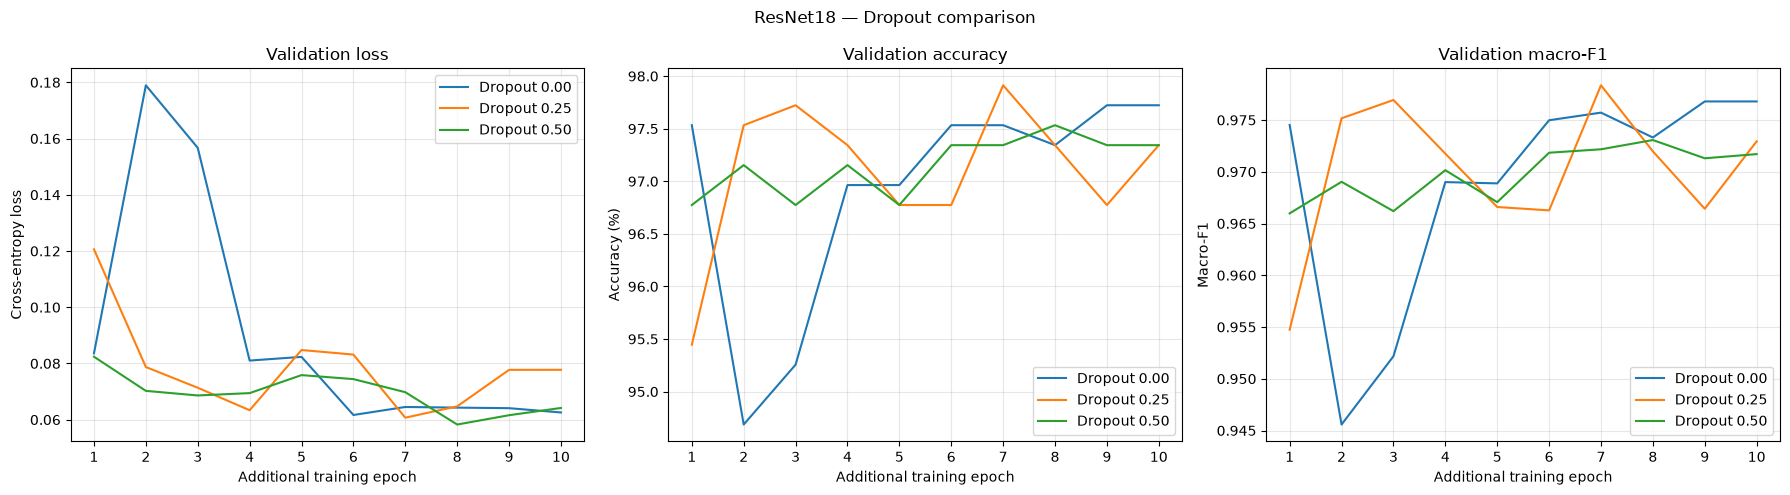

Figure saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\figures\resnet18_dropout_comparison.png
Selected dropout: 0.25
Selected checkpoint: resnet18_dropout_0.25_best.pt


In [13]:
import matplotlib.pyplot as plt

dropout_comparison = pd.DataFrame([
    dropout0_result,
    dropout025_result,
    dropout05_result,
]).sort_values(
    ["val_macro_f1", "val_accuracy", "val_loss"],
    ascending=[False, False, True]
).reset_index(drop=True)

dropout_comparison.to_csv(
    DROPOUT_DIR / "dropout_comparison.csv",
    index=False
)

display(
    dropout_comparison.style.format({
        "dropout": "{:.2f}",
        "val_accuracy": "{:.2%}",
        "val_macro_f1": "{:.4f}",
        "val_loss": "{:.4f}",
    })
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for probability, history in [
    (0.0, dropout0_history),
    (0.25, dropout025_history),
    (0.5, dropout05_history),
]:
    label = f"Dropout {probability:.2f}"

    axes[0].plot(
        history["epoch"], history["val_loss"], label=label
    )
    axes[1].plot(
        history["epoch"], history["val_accuracy"] * 100,
        label=label
    )
    axes[2].plot(
        history["epoch"], history["val_macro_f1"],
        label=label
    )

axes[0].set_title("Validation loss")
axes[0].set_ylabel("Cross-entropy loss")
axes[1].set_title("Validation accuracy")
axes[1].set_ylabel("Accuracy (%)")
axes[2].set_title("Validation macro-F1")
axes[2].set_ylabel("Macro-F1")

for ax in axes:
    ax.set_xlabel("Additional training epoch")
    ax.set_xticks(range(1, DROPOUT_EPOCHS + 1))
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("ResNet18 — Dropout comparison")
fig.tight_layout()

figure_dir = PROJECT_ROOT / "outputs" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
figure_path = figure_dir / "resnet18_dropout_comparison.png"

fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Figure saved:", figure_path)
print("Selected dropout: 0.25")
print("Selected checkpoint: resnet18_dropout_0.25_best.pt")

## What is happening in the next code?
This code counts how many training images each class has, in the same order as the `classes` list, and shows the counts in a table.
It prints the total number of training images and the ratio between the biggest and the smallest class, so you can see how balanced the data is (1.0 means perfectly balanced).
Finally, it prints a note that a balanced batch will have 16 images: 8 classes with 2 images each, so every class appears equally in each batch.

In [14]:
training_counts = (
    train_df["label"]
    .value_counts()
    .reindex(classes)
)

display(training_counts.rename("training_images").to_frame())

print("Total training images:", training_counts.sum())
print(
    "Largest / smallest class ratio:",
    round(training_counts.max() / training_counts.min(), 2)
)
print("Balanced batch: 8 classes × 2 images = 16 images")

,training_images
label,
ambulance,285
autobus,364
kamyun,306
kamyunet,430
minibus,304
savari,246
taxi,244
vanet,279


Total training images: 2458
Largest / smallest class ratio: 1.76
Balanced batch: 8 classes × 2 images = 16 images


## What is happening in the next code?
This code defines `BalancedBatchSampler`, a custom sampler that builds every batch with the same number of images from each class (2 images × 8 classes = 16 images). It checks that every class has at least 2 images.
For each batch, it takes 2 images from each class's shuffled list, and when a class runs out of images, it reshuffles that class and starts again. So small classes are repeated more often, and big classes are not over-represented. The batch order inside is shuffled, and the seed changes each epoch, so epochs differ but stay repeatable.
One epoch is set to 154 batches. Finally, it creates the sampler, takes one batch of indices (no images are loaded), and shows how many images of each class are in it, plus the batch size, the batches per epoch, and the total image draws per epoch (154 × 16).

In [15]:
from torch.utils.data import Sampler


class BalancedBatchSampler(Sampler):
    def __init__(
        self,
        labels,
        samples_per_class=2,
        batches_per_epoch=154,
        seed=42
    ):
        self.labels = np.asarray(labels)
        self.class_names = sorted(set(labels))
        self.samples_per_class = samples_per_class
        self.batches_per_epoch = batches_per_epoch
        self.seed = seed
        self.epoch = 0

        self.indices_by_class = {
            name: np.flatnonzero(self.labels == name)
            for name in self.class_names
        }

        if any(
            len(indices) < samples_per_class
            for indices in self.indices_by_class.values()
        ):
            raise ValueError("Each class needs at least 2 images.")

    def __len__(self):
        return self.batches_per_epoch

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        self.epoch += 1

        pools = {
            name: rng.permutation(indices)
            for name, indices in self.indices_by_class.items()
        }
        positions = {name: 0 for name in self.class_names}

        for _ in range(self.batches_per_epoch):
            batch = []

            for name in self.class_names:
                position = positions[name]
                pool = pools[name]

                if position + self.samples_per_class > len(pool):
                    pool = rng.permutation(self.indices_by_class[name])
                    pools[name] = pool
                    position = 0

                batch.extend(
                    pool[
                        position:position + self.samples_per_class
                    ].tolist()
                )
                positions[name] = position + self.samples_per_class

            rng.shuffle(batch)
            yield batch


balanced_sampler = BalancedBatchSampler(
    train_dataset.df["label"].tolist(),
    samples_per_class=2,
    batches_per_epoch=154,
    seed=42
)

first_batch = next(iter(balanced_sampler))
batch_labels = train_dataset.df.iloc[first_batch]["label"]

display(
    batch_labels.value_counts()
    .reindex(classes)
    .rename("images_in_batch")
    .to_frame()
)

print("Batch size:", len(first_batch))
print("Batches per epoch:", len(balanced_sampler))
print("Image draws per balanced epoch:", len(balanced_sampler) * 16)

,images_in_batch
label,
ambulance,2
autobus,2
kamyun,2
kamyunet,2
minibus,2
savari,2
taxi,2
vanet,2


Batch size: 16
Batches per epoch: 154
Image draws per balanced epoch: 2464


## What is happening in the next code?
This code prepares a sampling experiment: it compares normal random batches with balanced batches (2 images per class), using the best dropout 0.25 model as the starting point. It sets 10 epochs, seed 42, and creates a `sampling` output folder.
The function `build_sampling_model` builds a ResNet18 with a Dropout(0.25) layer before the final layer, loads the saved weights from the dropout checkpoint, freezes all layers, and unfreezes only `layer3`, `layer4`, and the final block.
The function `make_sampling_loader` creates the training loader in two modes: "standard" (random shuffle, 16 images per batch) or "balanced" (uses `BalancedBatchSampler`, 154 batches per epoch). Both use the same seed, so the comparison is fair.
Finally, it loads the starting checkpoint and prints its validation accuracy and macro F1, the number of epochs, the number of batches in each mode, and the dropout and augmentation settings. No training starts yet.

In [16]:
SAMPLING_EPOCHS = 10
SAMPLING_SEED = 42

SAMPLING_START_PATH = (
    DROPOUT_DIR / "resnet18_dropout_0.25_best.pt"
)

SAMPLING_DIR = PROJECT_ROOT / "outputs" / "sampling"
SAMPLING_DIR.mkdir(parents=True, exist_ok=True)


def build_sampling_model():
    saved = torch.load(
        SAMPLING_START_PATH,
        map_location="cpu",
        weights_only=True
    )

    model = resnet18(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(p=0.25),
        nn.Linear(model.fc.in_features, len(classes))
    )
    model.load_state_dict(saved["model_state_dict"])

    for parameter in model.parameters():
        parameter.requires_grad = False

    for layer in [model.layer3, model.layer4, model.fc]:
        for parameter in layer.parameters():
            parameter.requires_grad = True

    return model.to(DEVICE)


def make_sampling_loader(mode):
    generator = torch.Generator().manual_seed(SAMPLING_SEED)

    if mode == "standard":
        return DataLoader(
            train_dataset,
            batch_size=16,
            shuffle=True,
            num_workers=0,
            generator=generator
        )

    if mode == "balanced":
        sampler = BalancedBatchSampler(
            train_dataset.df["label"].tolist(),
            samples_per_class=2,
            batches_per_epoch=154,
            seed=SAMPLING_SEED
        )

        return DataLoader(
            train_dataset,
            batch_sampler=sampler,
            num_workers=0,
            generator=generator
        )

    raise ValueError("Mode must be 'standard' or 'balanced'.")


starting = torch.load(
    SAMPLING_START_PATH,
    map_location="cpu",
    weights_only=True
)

print("Starting checkpoint:", SAMPLING_START_PATH.name)
print("Starting accuracy:", f"{starting['val_accuracy']:.2%}")
print("Starting macro-F1:", f"{starting['val_macro_f1']:.4f}")
print("Epochs per experiment:", SAMPLING_EPOCHS)
print("Standard batches:", len(make_sampling_loader("standard")))
print("Balanced batches:", len(make_sampling_loader("balanced")))
print("Dropout: 0.25")
print("Augmentation: unchanged")

Starting checkpoint: resnet18_dropout_0.25_best.pt
Starting accuracy: 97.91%
Starting macro-F1: 0.9784
Epochs per experiment: 10
Standard batches: 154
Balanced batches: 154
Dropout: 0.25
Augmentation: unchanged


## What is happening in the next code?
This code defines `run_sampling_experiment`, which trains the best dropout (0.25) ResNet18 once, using either "standard" random batches or "balanced" batches (2 images per class). Before it starts, it resets the random seeds, builds the model and the loader for the chosen mode, and stops with an error if results for that mode already exist, so old files are not overwritten.
Before training, it evaluates the starting model and saves it as a backup checkpoint (epoch 0). Then each epoch it trains `layer3`, `layer4`, and the final block (dropout is active here), keeps all BatchNorm layers in eval mode, and measures loss, accuracy, and macro F1 on the validation data.
A new checkpoint is saved only if the validation macro F1 improves (accuracy and loss break ties). The config also records the batches and image draws per epoch, so the two modes can be compared fairly. The history of every epoch is written to a CSV file.
At the end, it saves a one-row result file, prints the best epoch, and returns the history table and the result summary.

In [17]:
def run_sampling_experiment(mode):
    random.seed(SAMPLING_SEED)
    np.random.seed(SAMPLING_SEED)
    torch.manual_seed(SAMPLING_SEED)

    model = build_sampling_model()
    loader = make_sampling_loader(mode)

    optimizer = torch.optim.AdamW(
        [
            {"params": model.layer3.parameters(), "lr": 3e-6},
            {"params": model.layer4.parameters(), "lr": 1e-5},
            {"params": model.fc.parameters(), "lr": 3e-5},
        ],
        weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )
    criterion = nn.CrossEntropyLoss()

    tag = f"resnet18_sampling_{mode}"
    checkpoint_path = SAMPLING_DIR / f"{tag}_best.pt"
    history_path = SAMPLING_DIR / f"{tag}_history.csv"

    if checkpoint_path.exists() or history_path.exists():
        raise FileExistsError(f"Results already exist: {tag}")

    starting = torch.load(
        SAMPLING_START_PATH,
        map_location="cpu",
        weights_only=True
    )
    config = {
        **starting["config"],
        "sampling": mode,
        "epochs": SAMPLING_EPOCHS,
        "seed": SAMPLING_SEED,
        "starting_checkpoint": SAMPLING_START_PATH.name,
        "batches_per_epoch": len(loader),
        "image_draws_per_epoch": (
            len(train_dataset) if mode == "standard"
            else len(loader) * 16
        ),
    }

    def evaluate():
        model.eval()
        total_loss = 0.0
        true_labels, predictions = [], []

        with torch.inference_mode():
            for images, labels in val_loader:
                labels = labels.to(DEVICE)
                logits = model(images.to(DEVICE))

                total_loss += (
                    criterion(logits, labels).item() * labels.size(0)
                )
                true_labels.extend(labels.cpu().tolist())
                predictions.extend(logits.argmax(1).cpu().tolist())

        return {
            "val_loss": total_loss / len(val_dataset),
            "val_accuracy": accuracy_score(true_labels, predictions),
            "val_macro_f1": f1_score(
                true_labels,
                predictions,
                labels=list(range(len(classes))),
                average="macro",
                zero_division=0
            ),
        }

    def save_checkpoint(epoch, metrics):
        torch.save({
            "epoch": epoch,
            "stage": (
                "starting_checkpoint" if epoch == 0
                else "sampling_finetuning"
            ),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "class_to_idx": class_to_idx,
            **metrics,
            "config": config,
        }, checkpoint_path)

    best_metrics = evaluate()
    best_epoch = 0
    save_checkpoint(0, best_metrics)
    history = []

    print(
        f"\nSampling: {mode} | "
        f"Starting accuracy: {best_metrics['val_accuracy']:.2%} | "
        f"Starting macro-F1: {best_metrics['val_macro_f1']:.4f}",
        flush=True
    )

    for epoch in range(1, SAMPLING_EPOCHS + 1):
        started = time.perf_counter()

        model.eval()
        model.layer3.train()
        model.layer4.train()
        model.fc.train()

        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()

        learning_rates = [
            group["lr"] for group in optimizer.param_groups
        ]
        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)
            total_correct += (
                logits.argmax(1) == labels
            ).sum().item()
            total_count += labels.size(0)

        metrics = evaluate()
        scheduler.step(metrics["val_loss"])

        score = (
            metrics["val_macro_f1"],
            metrics["val_accuracy"],
            -metrics["val_loss"],
        )
        best_score = (
            best_metrics["val_macro_f1"],
            best_metrics["val_accuracy"],
            -best_metrics["val_loss"],
        )

        if score > best_score:
            best_metrics = metrics.copy()
            best_epoch = epoch
            save_checkpoint(epoch, metrics)

        history.append({
            "epoch": epoch,
            "train_loss": total_loss / total_count,
            "train_accuracy": total_correct / total_count,
            **metrics,
            "layer3_lr": learning_rates[0],
            "layer4_lr": learning_rates[1],
            "fc_lr": learning_rates[2],
            "seconds": time.perf_counter() - started,
        })
        pd.DataFrame(history).to_csv(history_path, index=False)

        print(
            f"Epoch {epoch:02d}/{SAMPLING_EPOCHS} | "
            f"Train accuracy: {total_correct / total_count:.2%} | "
            f"Val accuracy: {metrics['val_accuracy']:.2%} | "
            f"Val macro-F1: {metrics['val_macro_f1']:.4f} | "
            f"Val loss: {metrics['val_loss']:.4f}",
            flush=True
        )

    result = {
        "sampling": mode,
        "best_epoch": best_epoch,
        **best_metrics,
        "checkpoint": str(checkpoint_path),
    }
    pd.DataFrame([result]).to_csv(
        SAMPLING_DIR / f"{tag}_result.csv",
        index=False
    )

    print(
        f"Best retained epoch: {best_epoch} | "
        f"Accuracy: {best_metrics['val_accuracy']:.2%} | "
        f"Macro-F1: {best_metrics['val_macro_f1']:.4f}"
    )

    return pd.DataFrame(history), result


print("Sampling comparison training loop ready.")

Sampling comparison training loop ready.


In [18]:
standard_history, standard_result = run_sampling_experiment("standard")


Sampling: standard | Starting accuracy: 97.91% | Starting macro-F1: 0.9784
Epoch 01/10 | Train accuracy: 99.84% | Val accuracy: 97.53% | Val macro-F1: 0.9754 | Val loss: 0.0695
Epoch 02/10 | Train accuracy: 100.00% | Val accuracy: 97.53% | Val macro-F1: 0.9743 | Val loss: 0.0613
Epoch 03/10 | Train accuracy: 99.96% | Val accuracy: 97.34% | Val macro-F1: 0.9722 | Val loss: 0.0838
Epoch 04/10 | Train accuracy: 100.00% | Val accuracy: 97.34% | Val macro-F1: 0.9734 | Val loss: 0.0795
Epoch 05/10 | Train accuracy: 99.43% | Val accuracy: 96.20% | Val macro-F1: 0.9587 | Val loss: 0.0967
Epoch 06/10 | Train accuracy: 99.88% | Val accuracy: 96.77% | Val macro-F1: 0.9671 | Val loss: 0.0788
Epoch 07/10 | Train accuracy: 99.96% | Val accuracy: 97.72% | Val macro-F1: 0.9766 | Val loss: 0.0586
Epoch 08/10 | Train accuracy: 99.92% | Val accuracy: 96.96% | Val macro-F1: 0.9688 | Val loss: 0.0818
Epoch 09/10 | Train accuracy: 99.88% | Val accuracy: 98.10% | Val macro-F1: 0.9800 | Val loss: 0.0666
Epoc

In [19]:
balanced_history, balanced_result = run_sampling_experiment("balanced")


Sampling: balanced | Starting accuracy: 97.91% | Starting macro-F1: 0.9784
Epoch 01/10 | Train accuracy: 99.51% | Val accuracy: 97.53% | Val macro-F1: 0.9749 | Val loss: 0.0688
Epoch 02/10 | Train accuracy: 99.47% | Val accuracy: 96.77% | Val macro-F1: 0.9674 | Val loss: 0.0703
Epoch 03/10 | Train accuracy: 99.76% | Val accuracy: 97.15% | Val macro-F1: 0.9710 | Val loss: 0.0986
Epoch 04/10 | Train accuracy: 99.80% | Val accuracy: 97.91% | Val macro-F1: 0.9778 | Val loss: 0.0689
Epoch 05/10 | Train accuracy: 99.88% | Val accuracy: 97.72% | Val macro-F1: 0.9761 | Val loss: 0.0625
Epoch 06/10 | Train accuracy: 99.88% | Val accuracy: 96.77% | Val macro-F1: 0.9679 | Val loss: 0.0857
Epoch 07/10 | Train accuracy: 99.96% | Val accuracy: 97.72% | Val macro-F1: 0.9770 | Val loss: 0.0606
Epoch 08/10 | Train accuracy: 99.96% | Val accuracy: 96.96% | Val macro-F1: 0.9687 | Val loss: 0.0693
Epoch 09/10 | Train accuracy: 99.92% | Val accuracy: 98.29% | Val macro-F1: 0.9819 | Val loss: 0.0588
Epoch 

,sampling,best_epoch,val_loss,val_accuracy,val_macro_f1,checkpoint
0,balanced,9,0.0588,98.29%,0.9819,D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\sampling\resnet18_sampling_balanced_best.pt
1,standard,9,0.0666,98.10%,0.9800,D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\sampling\resnet18_sampling_standard_best.pt


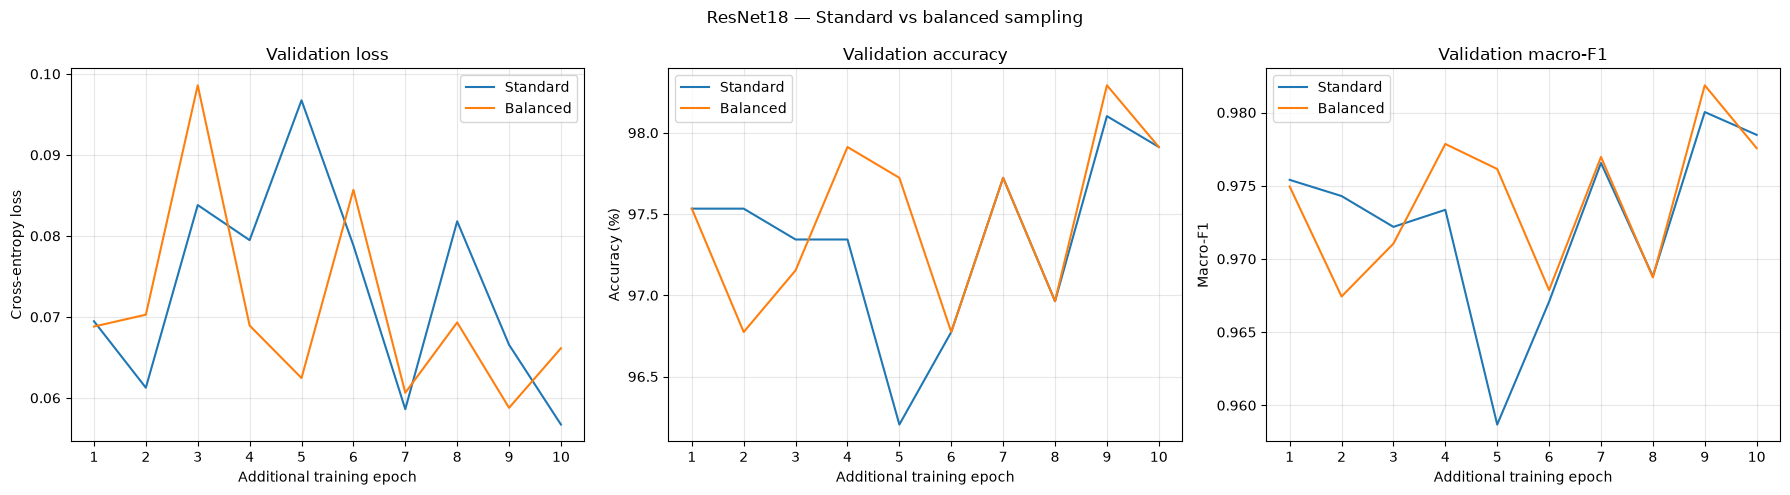

Figure saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\figures\resnet18_sampling_comparison.png
Selected sampling: balanced
Selected checkpoint: resnet18_sampling_balanced_best.pt


In [20]:
sampling_comparison = pd.DataFrame([
    standard_result,
    balanced_result,
]).sort_values(
    ["val_macro_f1", "val_accuracy", "val_loss"],
    ascending=[False, False, True]
).reset_index(drop=True)

sampling_comparison.to_csv(
    SAMPLING_DIR / "sampling_comparison.csv",
    index=False
)

display(
    sampling_comparison.style.format({
        "val_accuracy": "{:.2%}",
        "val_macro_f1": "{:.4f}",
        "val_loss": "{:.4f}",
    })
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for label, history in [
    ("Standard", standard_history),
    ("Balanced", balanced_history),
]:
    axes[0].plot(
        history["epoch"], history["val_loss"], label=label
    )
    axes[1].plot(
        history["epoch"], history["val_accuracy"] * 100,
        label=label
    )
    axes[2].plot(
        history["epoch"], history["val_macro_f1"],
        label=label
    )

axes[0].set_title("Validation loss")
axes[0].set_ylabel("Cross-entropy loss")
axes[1].set_title("Validation accuracy")
axes[1].set_ylabel("Accuracy (%)")
axes[2].set_title("Validation macro-F1")
axes[2].set_ylabel("Macro-F1")

for ax in axes:
    ax.set_xlabel("Additional training epoch")
    ax.set_xticks(range(1, SAMPLING_EPOCHS + 1))
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("ResNet18 — Standard vs balanced sampling")
fig.tight_layout()

figure_dir = PROJECT_ROOT / "outputs" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
figure_path = figure_dir / "resnet18_sampling_comparison.png"

fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Figure saved:", figure_path)
print("Selected sampling: balanced")
print("Selected checkpoint: resnet18_sampling_balanced_best.pt")

## What is happening in the next code?
This code prepares a loss comparison experiment: it will compare two ways of measuring the error, Cross-Entropy (`ce`) and Binary Cross-Entropy (`bce`), using the best balanced-sampling ResNet18 as the starting point. It sets 10 epochs, seed 42, and creates a `loss_comparison` output folder.
The function `build_loss_model` builds a ResNet18 with Dropout(0.25) before the final layer, loads the saved weights from the balanced-sampling checkpoint, freezes all layers, and unfreezes only `layer3`, `layer4`, and the final block.
The function `classification_loss` calculates the loss in one of two ways. `ce` compares the model's scores with the correct class directly. `bce` turns each label into a one-hot vector (1 for the correct class, 0 for the others) and treats every class as its own yes/no question.
Finally, it loads the starting checkpoint and prints its validation accuracy and macro F1, the number of epochs, and the sampling and dropout settings. No training starts yet.

In [26]:
import torch.nn.functional as F

LOSS_EPOCHS = 10
LOSS_SEED = 42

LOSS_START_PATH = (
    SAMPLING_DIR / "resnet18_sampling_balanced_best.pt"
)

LOSS_DIR = PROJECT_ROOT / "outputs" / "loss_comparison"
LOSS_DIR.mkdir(parents=True, exist_ok=True)


def build_loss_model():
    saved = torch.load(
        LOSS_START_PATH,
        map_location="cpu",
        weights_only=True
    )

    model = resnet18(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(p=0.25),
        nn.Linear(model.fc.in_features, len(classes))
    )
    model.load_state_dict(saved["model_state_dict"])

    for parameter in model.parameters():
        parameter.requires_grad = False

    for layer in [model.layer3, model.layer4, model.fc]:
        for parameter in layer.parameters():
            parameter.requires_grad = True

    return model.to(DEVICE)


def classification_loss(logits, labels, loss_name):
    if loss_name == "ce":
        return F.cross_entropy(logits, labels)

    if loss_name == "bce":
        targets = F.one_hot(
            labels,
            num_classes=len(classes)
        ).to(dtype=logits.dtype)

        return F.binary_cross_entropy_with_logits(
            logits, targets
        )

    raise ValueError("Loss must be 'ce' or 'bce'.")


starting = torch.load(
    LOSS_START_PATH,
    map_location="cpu",
    weights_only=True
)

print("Starting checkpoint:", LOSS_START_PATH.name)
print("Starting accuracy:", f"{starting['val_accuracy']:.2%}")
print("Starting macro-F1:", f"{starting['val_macro_f1']:.4f}")
print("Epochs per experiment:", LOSS_EPOCHS)
print("Sampling: balanced")
print("Dropout: 0.25")
print("Loss comparison preparation ready.")

Starting checkpoint: resnet18_sampling_balanced_best.pt
Starting accuracy: 98.29%
Starting macro-F1: 0.9819
Epochs per experiment: 10
Sampling: balanced
Dropout: 0.25
Loss comparison preparation ready.


## What is happening in the next code?
This code defines `run_loss_experiment`, which trains the best balanced-sampling ResNet18 once with a chosen loss: Cross-Entropy (`ce`) or Binary Cross-Entropy (`bce`). Before it starts, it checks the loss name, resets the random seeds, builds the model, and creates the balanced loader. It stops with an error if results for that loss already exist, so old files are not overwritten.
Before training, it evaluates the starting model and saves it as a backup checkpoint (epoch 0). Then each epoch it trains `layer3`, `layer4`, and the final block using the chosen loss, keeps all BatchNorm layers in eval mode, and measures loss, accuracy, and macro F1 on the validation data.
A new checkpoint is saved only if the validation macro F1 improves (accuracy and loss break ties). The scheduler now watches the validation macro F1 (not the loss) and halves the learning rates if it does not improve for 2 epochs. This is because the validation loss of `ce` and `bce` has different scales and cannot be compared fairly.
At the end, it saves a one-row result file, prints the best epoch, and returns the history table and the result summary.

In [27]:
def run_loss_experiment(loss_name):
    if loss_name not in ("ce", "bce"):
        raise ValueError("Loss must be 'ce' or 'bce'.")

    random.seed(LOSS_SEED)
    np.random.seed(LOSS_SEED)
    torch.manual_seed(LOSS_SEED)

    model = build_loss_model()
    loader = make_sampling_loader("balanced")

    optimizer = torch.optim.AdamW(
        [
            {"params": model.layer3.parameters(), "lr": 3e-6},
            {"params": model.layer4.parameters(), "lr": 1e-5},
            {"params": model.fc.parameters(), "lr": 3e-5},
        ],
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        threshold=0.0,
        threshold_mode="abs"
    )

    tag = f"resnet18_loss_{loss_name}"
    checkpoint_path = LOSS_DIR / f"{tag}_best.pt"
    history_path = LOSS_DIR / f"{tag}_history.csv"

    if checkpoint_path.exists() or history_path.exists():
        raise FileExistsError(f"Results already exist: {tag}")

    starting = torch.load(
        LOSS_START_PATH,
        map_location="cpu",
        weights_only=True
    )

    config = {
        **starting["config"],
        "loss": loss_name,
        "epochs": LOSS_EPOCHS,
        "seed": LOSS_SEED,
        "starting_checkpoint": LOSS_START_PATH.name,
        "scheduler_monitor": "validation_macro_f1",
        "selection_metric": "validation_macro_f1",
    }

    def evaluate():
        model.eval()
        total_loss = 0.0
        true_labels, predictions = [], []

        with torch.inference_mode():
            for images, labels in val_loader:
                labels = labels.to(DEVICE)
                logits = model(images.to(DEVICE))

                loss = classification_loss(logits, labels, loss_name)
                total_loss += loss.item() * labels.size(0)

                true_labels.extend(labels.cpu().tolist())
                predictions.extend(logits.argmax(1).cpu().tolist())

        return {
            "val_loss": total_loss / len(val_dataset),
            "val_accuracy": accuracy_score(true_labels, predictions),
            "val_macro_f1": f1_score(
                true_labels,
                predictions,
                labels=list(range(len(classes))),
                average="macro",
                zero_division=0
            ),
        }

    def save_checkpoint(epoch, metrics):
        torch.save({
            "epoch": epoch,
            "stage": (
                "starting_checkpoint" if epoch == 0
                else "loss_finetuning"
            ),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "class_to_idx": class_to_idx,
            **metrics,
            "config": config,
        }, checkpoint_path)

    best_metrics = evaluate()
    best_epoch = 0
    save_checkpoint(0, best_metrics)
    history = []

    print(
        f"\nLoss: {loss_name.upper()} | "
        f"Starting accuracy: {best_metrics['val_accuracy']:.2%} | "
        f"Starting macro-F1: {best_metrics['val_macro_f1']:.4f}",
        flush=True
    )

    for epoch in range(1, LOSS_EPOCHS + 1):
        started = time.perf_counter()

        model.eval()
        model.layer3.train()
        model.layer4.train()
        model.fc.train()

        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()

        learning_rates = [
            group["lr"] for group in optimizer.param_groups
        ]
        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = classification_loss(logits, labels, loss_name)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)
            total_correct += (
                logits.argmax(1) == labels
            ).sum().item()
            total_count += labels.size(0)

        metrics = evaluate()
        scheduler.step(metrics["val_macro_f1"])

        score = (
            metrics["val_macro_f1"],
            metrics["val_accuracy"],
            -metrics["val_loss"],
        )
        best_score = (
            best_metrics["val_macro_f1"],
            best_metrics["val_accuracy"],
            -best_metrics["val_loss"],
        )

        if score > best_score:
            best_metrics = metrics.copy()
            best_epoch = epoch
            save_checkpoint(epoch, metrics)

        history.append({
            "epoch": epoch,
            "train_loss": total_loss / total_count,
            "train_accuracy": total_correct / total_count,
            **metrics,
            "layer3_lr": learning_rates[0],
            "layer4_lr": learning_rates[1],
            "fc_lr": learning_rates[2],
            "seconds": time.perf_counter() - started,
        })

        pd.DataFrame(history).to_csv(history_path, index=False)

        print(
            f"Epoch {epoch:02d}/{LOSS_EPOCHS} | "
            f"Train accuracy: {total_correct / total_count:.2%} | "
            f"Val accuracy: {metrics['val_accuracy']:.2%} | "
            f"Val macro-F1: {metrics['val_macro_f1']:.4f} | "
            f"Val loss: {metrics['val_loss']:.4f}",
            flush=True
        )

    result = {
        "loss": loss_name,
        "best_epoch": best_epoch,
        **best_metrics,
        "checkpoint": str(checkpoint_path),
    }

    pd.DataFrame([result]).to_csv(
        LOSS_DIR / f"{tag}_result.csv",
        index=False
    )

    print(
        f"Best retained epoch: {best_epoch} | "
        f"Accuracy: {best_metrics['val_accuracy']:.2%} | "
        f"Macro-F1: {best_metrics['val_macro_f1']:.4f}"
    )

    return pd.DataFrame(history), result


print("CE vs BCE training loop ready.")

CE vs BCE training loop ready.


In [28]:
ce_history, ce_result = run_loss_experiment("ce")


Loss: CE | Starting accuracy: 98.29% | Starting macro-F1: 0.9819
Epoch 01/10 | Train accuracy: 99.96% | Val accuracy: 98.29% | Val macro-F1: 0.9824 | Val loss: 0.0715
Epoch 02/10 | Train accuracy: 99.96% | Val accuracy: 96.77% | Val macro-F1: 0.9691 | Val loss: 0.0967
Epoch 03/10 | Train accuracy: 99.84% | Val accuracy: 96.02% | Val macro-F1: 0.9588 | Val loss: 0.1315
Epoch 04/10 | Train accuracy: 99.76% | Val accuracy: 97.91% | Val macro-F1: 0.9779 | Val loss: 0.0620
Epoch 05/10 | Train accuracy: 100.00% | Val accuracy: 98.48% | Val macro-F1: 0.9837 | Val loss: 0.0517
Epoch 06/10 | Train accuracy: 100.00% | Val accuracy: 98.67% | Val macro-F1: 0.9865 | Val loss: 0.0581
Epoch 07/10 | Train accuracy: 99.92% | Val accuracy: 97.34% | Val macro-F1: 0.9732 | Val loss: 0.0651
Epoch 08/10 | Train accuracy: 99.96% | Val accuracy: 98.29% | Val macro-F1: 0.9826 | Val loss: 0.0608
Epoch 09/10 | Train accuracy: 100.00% | Val accuracy: 98.29% | Val macro-F1: 0.9826 | Val loss: 0.0602
Epoch 10/10 |

In [29]:
bce_history, bce_result = run_loss_experiment("bce")


Loss: BCE | Starting accuracy: 98.29% | Starting macro-F1: 0.9819
Epoch 01/10 | Train accuracy: 99.88% | Val accuracy: 98.29% | Val macro-F1: 0.9832 | Val loss: 0.0325
Epoch 02/10 | Train accuracy: 99.84% | Val accuracy: 98.10% | Val macro-F1: 0.9807 | Val loss: 0.0276
Epoch 03/10 | Train accuracy: 99.96% | Val accuracy: 98.29% | Val macro-F1: 0.9836 | Val loss: 0.0276
Epoch 04/10 | Train accuracy: 100.00% | Val accuracy: 97.53% | Val macro-F1: 0.9734 | Val loss: 0.0275
Epoch 05/10 | Train accuracy: 99.96% | Val accuracy: 97.53% | Val macro-F1: 0.9745 | Val loss: 0.0308
Epoch 06/10 | Train accuracy: 100.00% | Val accuracy: 96.96% | Val macro-F1: 0.9707 | Val loss: 0.0313
Epoch 07/10 | Train accuracy: 99.92% | Val accuracy: 98.29% | Val macro-F1: 0.9828 | Val loss: 0.0264
Epoch 08/10 | Train accuracy: 100.00% | Val accuracy: 98.67% | Val macro-F1: 0.9868 | Val loss: 0.0275
Epoch 09/10 | Train accuracy: 100.00% | Val accuracy: 97.91% | Val macro-F1: 0.9778 | Val loss: 0.0260
Epoch 10/10

,loss,best_epoch,val_loss,val_accuracy,val_macro_f1,checkpoint
0,bce,8,0.0275,98.67%,0.9868,D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\loss_comparison\resnet18_loss_bce_best.pt
1,ce,6,0.0581,98.67%,0.9865,D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\loss_comparison\resnet18_loss_ce_best.pt


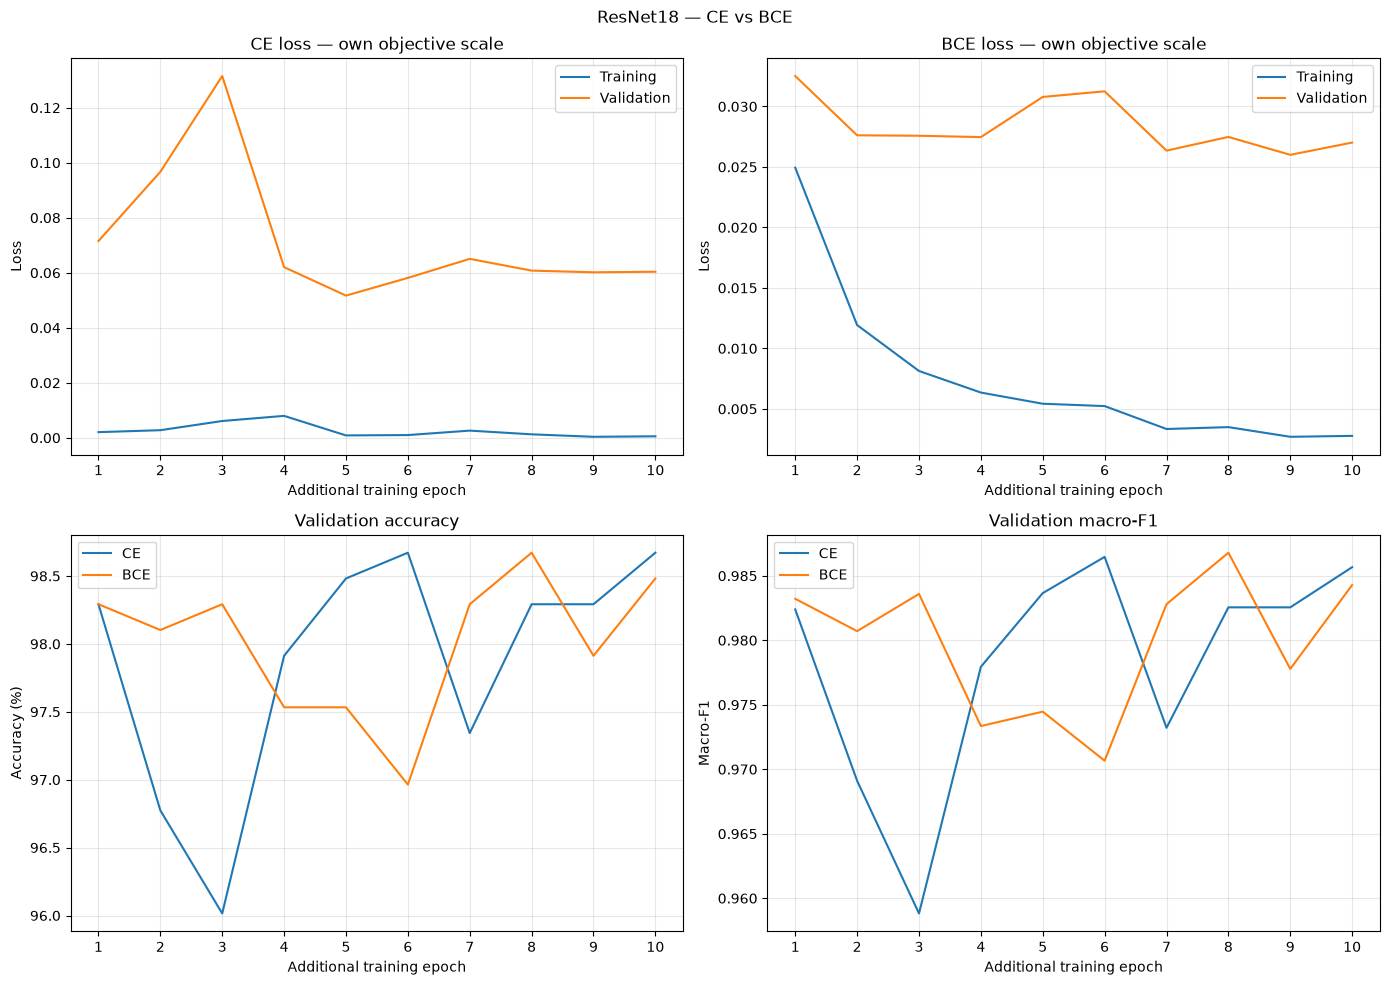

Figure saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\figures\resnet18_loss_comparison.png
Selected checkpoint: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\loss_comparison\resnet18_loss_bce_best.pt


In [ ]:
loss_comparison = pd.DataFrame([
    ce_result,
    bce_result,
]).sort_values(
    ["val_macro_f1", "val_accuracy"],
    ascending=[False, False]
).reset_index(drop=True)

loss_comparison.to_csv(
    LOSS_DIR / "loss_comparison.csv",
    index=False
)

display(
    loss_comparison.style.format({
        "val_accuracy": "{:.2%}",
        "val_macro_f1": "{:.4f}",
        "val_loss": "{:.4f}",
    })
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, label, history in [
    (axes[0, 0], "CE", ce_history),
    (axes[0, 1], "BCE", bce_history),
]:
    ax.plot(history["epoch"], history["train_loss"], label="Training")
    ax.plot(history["epoch"], history["val_loss"], label="Validation")
    ax.set_title(f"{label} loss — own objective scale")
    ax.set_ylabel("Loss")

for label, history in [
    ("CE", ce_history),
    ("BCE", bce_history),
]:
    axes[1, 0].plot(
        history["epoch"], history["val_accuracy"] * 100,
        label=label
    )
    axes[1, 1].plot(
        history["epoch"], history["val_macro_f1"],
        label=label
    )

axes[1, 0].set_title("Validation accuracy")
axes[1, 0].set_ylabel("Accuracy (%)")
axes[1, 1].set_title("Validation macro-F1")
axes[1, 1].set_ylabel("Macro-F1")

for ax in axes.ravel():
    ax.set_xlabel("Additional training epoch")
    ax.set_xticks(range(1, LOSS_EPOCHS + 1))
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("ResNet18 — CE vs BCE")
fig.tight_layout()

figure_dir = PROJECT_ROOT / "outputs" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
figure_path = figure_dir / "resnet18_loss_comparison.png"

fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Figure saved:", figure_path)
print("Selected checkpoint:", bce_result["checkpoint"])

## What is happening in the next code?
This code prepares to continue training the best BCE model for 5 more epochs. It loads the best BCE checkpoint, builds the model with Dropout(0.25), and puts the saved weights back into it.
It also restores the optimizer and the scheduler from the checkpoint, so training continues with the same learning rates and the same scheduler progress, and does not start from zero. The scheduler still watches the validation macro F1.
Then it resets the random seeds, creates the balanced training loader, and creates a `bce_continuation` output folder.
Finally, it prints the starting epoch, accuracy, and macro F1, the number of extra epochs, and the restored learning rate of each layer group (`layer3`, `layer4`, `fc`). No training starts yet.

In [31]:
CONTINUE_EPOCHS = 5

continuation_start = torch.load(
    LOSS_DIR / "resnet18_loss_bce_best.pt",
    map_location="cpu",
    weights_only=True
)

continuation_model = build_loss_model()
continuation_model.load_state_dict(
    continuation_start["model_state_dict"]
)

continuation_optimizer = torch.optim.AdamW(
    [
        {"params": continuation_model.layer3.parameters(), "lr": 3e-6},
        {"params": continuation_model.layer4.parameters(), "lr": 1e-5},
        {"params": continuation_model.fc.parameters(), "lr": 3e-5},
    ],
    weight_decay=1e-4
)
continuation_optimizer.load_state_dict(
    continuation_start["optimizer_state_dict"]
)

continuation_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        continuation_optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        threshold=0.0,
        threshold_mode="abs"
    )
)
continuation_scheduler.load_state_dict(
    continuation_start["scheduler_state_dict"]
)


random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

continuation_loader = make_sampling_loader("balanced")

CONTINUE_DIR = PROJECT_ROOT / "outputs" / "bce_continuation"
CONTINUE_DIR.mkdir(parents=True, exist_ok=True)

print("Starting BCE epoch:", continuation_start["epoch"])
print(
    "Starting accuracy:",
    f"{continuation_start['val_accuracy']:.2%}"
)
print(
    "Starting macro-F1:",
    f"{continuation_start['val_macro_f1']:.4f}"
)
print("Additional epochs:", CONTINUE_EPOCHS)

for name, group in zip(
    ["Layer 3", "Layer 4", "FC"],
    continuation_optimizer.param_groups
):
    print(f"{name} restored learning rate: {group['lr']}")

Starting BCE epoch: 8
Starting accuracy: 98.67%
Starting macro-F1: 0.9868
Additional epochs: 5
Layer 3 restored learning rate: 1.5e-06
Layer 4 restored learning rate: 5e-06
FC restored learning rate: 1.5e-05


## What is happening in the next code?
This code defines `continue_bce_training`, which trains the best BCE model for 5 more epochs, using the model, optimizer, scheduler, and balanced loader prepared in the previous cell. It stops with an error if continuation results already exist, so old files are not overwritten.
It first saves the starting model as a backup checkpoint (additional epoch 0). Then each epoch it trains `layer3`, `layer4`, and the final block with the BCE loss, keeps all BatchNorm layers in eval mode, and measures loss, accuracy, and macro F1 on the validation data.
A new checkpoint is saved only if the validation macro F1 improves (accuracy and loss break ties). The scheduler watches the validation macro F1 and halves the learning rates if it does not improve for 2 epochs. The config notes that random states were not restored, so this run is not an exact copy of what an uninterrupted run would have done.
At the end, it saves a one-row result file, prints the best additional epoch with its accuracy and macro F1, and returns the history table and the result summary.

In [32]:
def continue_bce_training():
    checkpoint_path = CONTINUE_DIR / "resnet18_bce_continued_best.pt"
    history_path = CONTINUE_DIR / "resnet18_bce_continued_history.csv"

    if checkpoint_path.exists() or history_path.exists():
        raise FileExistsError("Continuation results already exist.")

    model = continuation_model
    optimizer = continuation_optimizer
    scheduler = continuation_scheduler

    best_metrics = {
        key: continuation_start[key]
        for key in ["val_loss", "val_accuracy", "val_macro_f1"]
    }
    best_additional_epoch = 0
    history = []

    config = {
        **continuation_start["config"],
        "additional_epochs": CONTINUE_EPOCHS,
        "starting_checkpoint": "resnet18_loss_bce_best.pt",
        "starting_bce_epoch": continuation_start["epoch"],
        "random_states_restored": False,
    }

    def save_checkpoint(additional_epoch, metrics):
        torch.save({
            "epoch": continuation_start["epoch"] + additional_epoch,
            "additional_epoch": additional_epoch,
            "stage": (
                "starting_bce_checkpoint"
                if additional_epoch == 0
                else "bce_continuation"
            ),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "class_to_idx": class_to_idx,
            **metrics,
            "config": config,
        }, checkpoint_path)

    save_checkpoint(0, best_metrics)

    for additional_epoch in range(1, CONTINUE_EPOCHS + 1):
        started = time.perf_counter()

        model.eval()
        model.layer3.train()
        model.layer4.train()
        model.fc.train()

        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()

        learning_rates = [
            group["lr"] for group in optimizer.param_groups
        ]
        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for images, labels in continuation_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = classification_loss(logits, labels, "bce")
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)
            total_correct += (
                logits.argmax(1) == labels
            ).sum().item()
            total_count += labels.size(0)

        model.eval()
        val_loss = 0.0
        true_labels, predictions = [], []

        with torch.inference_mode():
            for images, labels in val_loader:
                labels = labels.to(DEVICE)
                logits = model(images.to(DEVICE))

                val_loss += (
                    classification_loss(logits, labels, "bce").item()
                    * labels.size(0)
                )
                true_labels.extend(labels.cpu().tolist())
                predictions.extend(logits.argmax(1).cpu().tolist())

        metrics = {
            "val_loss": val_loss / len(val_dataset),
            "val_accuracy": accuracy_score(true_labels, predictions),
            "val_macro_f1": f1_score(
                true_labels,
                predictions,
                labels=list(range(len(classes))),
                average="macro",
                zero_division=0
            ),
        }

        scheduler.step(metrics["val_macro_f1"])

        score = (
            metrics["val_macro_f1"],
            metrics["val_accuracy"],
            -metrics["val_loss"],
        )
        best_score = (
            best_metrics["val_macro_f1"],
            best_metrics["val_accuracy"],
            -best_metrics["val_loss"],
        )

        if score > best_score:
            best_metrics = metrics.copy()
            best_additional_epoch = additional_epoch
            save_checkpoint(additional_epoch, metrics)

        history.append({
            "additional_epoch": additional_epoch,
            "bce_epoch": continuation_start["epoch"] + additional_epoch,
            "train_loss": total_loss / total_count,
            "train_accuracy": total_correct / total_count,
            **metrics,
            "layer3_lr": learning_rates[0],
            "layer4_lr": learning_rates[1],
            "fc_lr": learning_rates[2],
            "seconds": time.perf_counter() - started,
        })
        pd.DataFrame(history).to_csv(history_path, index=False)

        print(
            f"Additional epoch {additional_epoch}/{CONTINUE_EPOCHS} | "
            f"Train accuracy: {total_correct / total_count:.2%} | "
            f"Val accuracy: {metrics['val_accuracy']:.2%} | "
            f"Val macro-F1: {metrics['val_macro_f1']:.4f} | "
            f"Val loss: {metrics['val_loss']:.4f}",
            flush=True
        )

    result = {
        "best_additional_epoch": best_additional_epoch,
        "best_bce_epoch": (
            continuation_start["epoch"] + best_additional_epoch
        ),
        **best_metrics,
        "checkpoint": str(checkpoint_path),
    }
    pd.DataFrame([result]).to_csv(
        CONTINUE_DIR / "continuation_result.csv",
        index=False
    )

    print(
        f"\nBest additional epoch: {best_additional_epoch} | "
        f"Accuracy: {best_metrics['val_accuracy']:.2%} | "
        f"Macro-F1: {best_metrics['val_macro_f1']:.4f}"
    )
    print("Checkpoint:", checkpoint_path)

    return pd.DataFrame(history), result


print("BCE continuation loop ready.")

BCE continuation loop ready.


In [33]:
continuation_history, continuation_result = continue_bce_training()

Additional epoch 1/5 | Train accuracy: 99.96% | Val accuracy: 98.67% | Val macro-F1: 0.9864 | Val loss: 0.0253
Additional epoch 2/5 | Train accuracy: 100.00% | Val accuracy: 98.67% | Val macro-F1: 0.9868 | Val loss: 0.0243
Additional epoch 3/5 | Train accuracy: 100.00% | Val accuracy: 98.67% | Val macro-F1: 0.9864 | Val loss: 0.0262
Additional epoch 4/5 | Train accuracy: 100.00% | Val accuracy: 98.67% | Val macro-F1: 0.9863 | Val loss: 0.0261
Additional epoch 5/5 | Train accuracy: 99.96% | Val accuracy: 98.86% | Val macro-F1: 0.9890 | Val loss: 0.0248

Best additional epoch: 5 | Accuracy: 98.86% | Macro-F1: 0.9890
Checkpoint: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\bce_continuation\resnet18_bce_continued_best.pt
